In [ ]:
# import kagglehub

# download dataset
# filepath = kagglehub.competition_download('titanic', output_dir='data')

100%|██████████| 34.1k/34.1k [00:00<00:00, 5.52MB/s]

Extracting files...


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xb


## 1. Exploratory Analysis

In [6]:
df_train = pd.read_csv('data/train.csv')
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


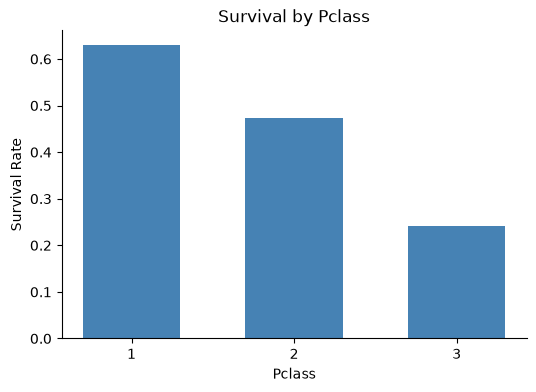

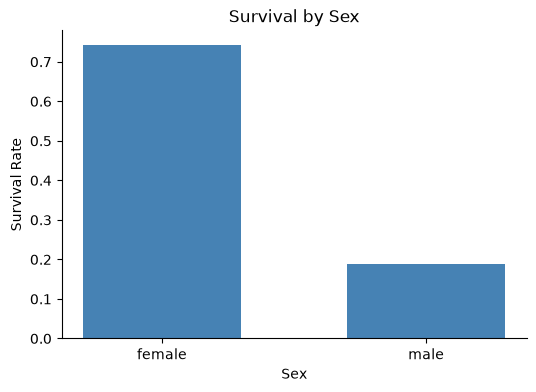

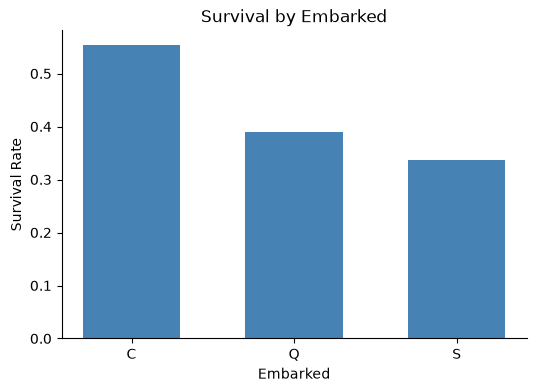

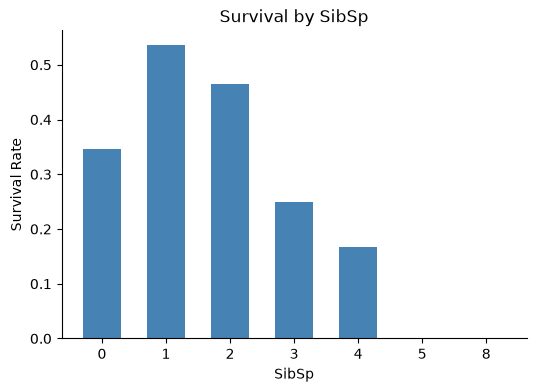

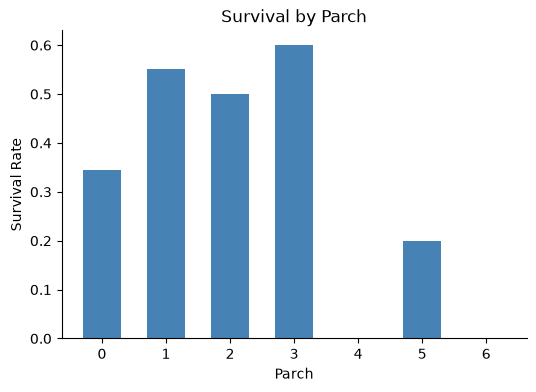

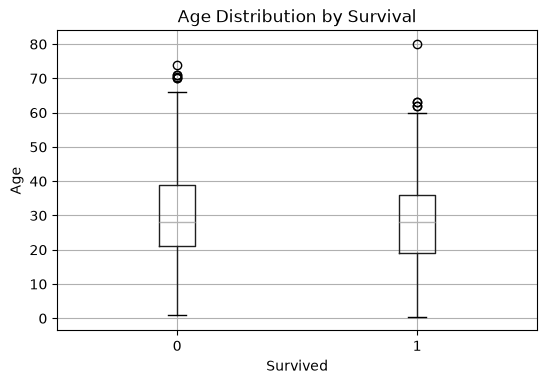

In [28]:
def target_by_cat(x_var: str):
    survived_by_class = df_train.groupby(x_var)['Survived'].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(survived_by_class.index.astype(str), survived_by_class, color='steelblue', width=0.6)
    ax.set_xlabel(x_var)
    ax.set_ylabel('Survival Rate')
    plot_title = "Survival by " + x_var
    ax.set_title(plot_title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()

def target_by_num(x_var: str):
    fig, ax = plt.subplots(figsize=(6,4))
    df_train.boxplot(column=x_var, by='Survived', ax=ax)
    ax.set_xlabel('Survived')
    ax.set_ylabel(x_var)
    plot_title = x_var + " Distribution by Survival"
    ax.set_title(plot_title)
    plt.suptitle('')  # removes the default pandas suptitle
    plt.show()

# target variable breakdown
target_by_cat('Pclass')
target_by_cat('Sex')
target_by_cat('Embarked')
target_by_cat('SibSp')
target_by_cat('Parch')

target_by_num('Age')
